# Lab 2 - Word Embeddings: Word2Vec, GloVe, FastText

**Topic:** word embeddings on a 30-sentence AI / healthcare / cybersecurity corpus (`corpus.txt`).

This notebook walks through `main.py` (Lab 2 solution) cell by cell. The code cells are the
script's own code, split at the part boundaries, so every printed result is the script's output.

| Part | What it demonstrates |
|---|---|
| A | Corpus preparation: lowercasing, punctuation removal, tokenisation, vocabulary, required words |
| B | Word2Vec with CBOW and Skip-gram, window 2 and 4; 5 nearest neighbours; CBOW vs Skip-gram comparison |
| C | GloVe-style embeddings from a word-word co-occurrence matrix (log + SVD); comparison with Word2Vec |
| D | FastText: subword (character n-gram) embeddings, including a word not in the corpus (`machine-learning`) |
| E | Cosine similarity of five word pairs under Word2Vec, GloVe and FastText; analysis |
| F | PCA projection to 2-D of 12 Word2Vec vectors, plotted inline |

Kernel: Speech Lab (.venv)


In [1]:
%matplotlib inline
import os, sys
from pathlib import Path

ROOT = Path.cwd().parent            # notebook lives in notebooks/
SOL = ROOT / "lab 2" / "solution" / "3) Word Embeddings (W2Vec, Glove, Fasttext)" / "3) Word Embeddings (W2Vec, Glove, Fasttext)"
assert SOL.exists(), SOL
sys.path.insert(0, str(SOL))
os.chdir(SOL)                       # corpus.txt must be in the cwd

# Same imports as main.py
import re
import numpy as np
import matplotlib.pyplot as plt

from gensim.models import Word2Vec, FastText
from sklearn.decomposition import PCA

## Part A - Corpus preparation

Each sentence is lowercased, every character except letters, digits, whitespace and `-` is removed,
and the line is split on whitespace. Keeping `-` means `machine-learning` stays one token. The
vocabulary is the sorted set of all tokens. The script then checks which of the required words
(`learn`, `learning`, `learned`, `learner`, `machine`, `machinelearning`, `cybersecurity`,
`healthcare`) and the unseen word `machine-learning` appear in that vocabulary.

Note: `main.py` does not remove stop words (the lab marks this as optional).

In [2]:
with open("corpus.txt", "r", encoding="utf-8") as file:
    sentences = file.readlines()


def preprocess(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-zA-Z0-9\s-]", "", sentence)
    return sentence.split()


tokenized_corpus = [preprocess(sentence) for sentence in sentences]

print("===== PART A: CORPUS PREPARATION =====")
print("Number of sentences:", len(tokenized_corpus))

print("\nTokenized sentences:")
for i, sentence in enumerate(tokenized_corpus[:5], 1):
    print(i, sentence)

vocabulary = sorted(set(
    word
    for sentence in tokenized_corpus
    for word in sentence
))

print("\nVocabulary size:", len(vocabulary))

required_words = [
    "learn",
    "learning",
    "learned",
    "learner",
    "machine",
    "machinelearning",
    "cybersecurity",
    "healthcare"
]

print("\nRequired words:")
for word in required_words:
    print(word, "->", "Present" if word in vocabulary else "Not Present")

print("\nUnseen word:")
print(
    "machine-learning ->",
    "Present" if "machine-learning" in vocabulary else "Not Present"
)

===== PART A: CORPUS PREPARATION =====
Number of sentences: 30

Tokenized sentences:
1 ['artificial', 'intelligence', 'is', 'transforming', 'modern', 'industries']
2 ['students', 'are', 'learning', 'artificial', 'intelligence', 'techniques']
3 ['the', 'student', 'uses', 'machine', 'learning', 'algorithms', 'for', 'intelligent', 'applications']
4 ['machine', 'learning', 'allows', 'computers', 'to', 'learn', 'from', 'data']
5 ['deep', 'learning', 'models', 'can', 'recognize', 'complex', 'patterns']

Vocabulary size: 129

Required words:
learn -> Present
learning -> Present
learned -> Present
learner -> Present
machine -> Present
machinelearning -> Present
cybersecurity -> Present
healthcare -> Present

Unseen word:
machine-learning -> Not Present


## Part B - Word2Vec (CBOW and Skip-gram, windows 2 and 4)

`train_word2vec(model_type, window)` trains gensim `Word2Vec` with 100-dimensional vectors,
`min_count=1`, `epochs=100` and `seed=42`. `sg=0` gives CBOW (predict the centre word from its
context); `sg=1` gives Skip-gram (predict the context from the centre word). The loop trains four
models: CBOW and Skip-gram, each with window 2 and window 4. For each model it prints the first
10 dimensions of the vectors for `learning`, `machine`, `intelligence` and `student`, and their
5 most similar words by cosine similarity.

In [3]:
def train_word2vec(model_type, window):
    sg = 0 if model_type == "CBOW" else 1

    model = Word2Vec(
        sentences=tokenized_corpus,
        vector_size=100,
        window=window,
        min_count=1,
        workers=4,
        sg=sg,
        seed=42,
        epochs=100
    )

    return model


selected_words = [
    "learning",
    "machine",
    "intelligence",
    "student"
]


word2vec_models = {}

print("\n===== PART B: WORD2VEC =====")

for model_type in ["CBOW", "Skip-gram"]:

    for window in [2, 4]:

        model = train_word2vec(model_type, window)

        key = f"{model_type}_window_{window}"
        word2vec_models[key] = model

        print("\n------------------------------")
        print(model_type, "Window =", window)
        print("------------------------------")

        for word in selected_words:

            print("\nVector for", word, ":")
            print(model.wv[word][:10])

            print("5 most similar:")
            print(model.wv.most_similar(word, topn=5))


===== PART B: WORD2VEC =====



------------------------------
CBOW Window = 2
------------------------------

Vector for learning :
[ 0.00999024  0.00392025 -0.01097445  0.0018153  -0.02375089  0.01001467
 -0.01729725  0.02309073 -0.06066126 -0.01841901]
5 most similar:
[('can', 0.9204833507537842), ('to', 0.9203330278396606), ('machine', 0.9112554788589478), ('machines', 0.9039852619171143), ('applications', 0.8899438381195068)]

Vector for machine :
[ 0.00717105  0.00756238 -0.00785904  0.00608229 -0.01358084 -0.00302192
  0.00014817  0.02041423 -0.03445328 -0.00011235]
5 most similar:
[('learning', 0.911255419254303), ('to', 0.8689316511154175), ('can', 0.8633392453193665), ('applications', 0.8473512530326843), ('networks', 0.8416590094566345)]

Vector for intelligence :
[ 0.00550912  0.00609949 -0.01542024  0.00985355 -0.00808396 -0.00703761
 -0.00830036  0.00829982 -0.02545604 -0.01180732]
5 most similar:
[('learning', 0.8187641501426697), ('machine', 0.7994056940078735), ('large', 0.7854689955711365), ('to', 


------------------------------
CBOW Window = 4
------------------------------

Vector for learning :
[ 0.02202826  0.00912124 -0.02625982  0.00171906 -0.03459901  0.01004575
 -0.01854531  0.04025367 -0.09378299 -0.02799784]
5 most similar:
[('can', 0.96733558177948), ('to', 0.9634977579116821), ('machine', 0.9629405736923218), ('machines', 0.957156240940094), ('applications', 0.9571505188941956)]

Vector for machine :
[ 0.01359262  0.01023185 -0.0165739   0.00574202 -0.0197634  -0.00300601
 -0.0008626   0.02964196 -0.05284992 -0.00571653]
5 most similar:
[('learning', 0.9629406332969666), ('can', 0.9419988989830017), ('to', 0.9402302503585815), ('applications', 0.9373241066932678), ('networks', 0.9319394826889038)]

Vector for intelligence :
[ 0.01106152  0.00792811 -0.02157051  0.00992261 -0.01242716 -0.00726828
 -0.0088389   0.01507442 -0.03897847 -0.01560796]
5 most similar:
[('learning', 0.9178161025047302), ('machine', 0.9083490967750549), ('can', 0.8976821303367615), ('data', 0.


------------------------------
Skip-gram Window = 2
------------------------------

Vector for learning :
[ 0.05994352  0.00023191 -0.05181327 -0.01823435 -0.0911833   0.00305254
 -0.03801896  0.1120544  -0.21345428 -0.05075901]
5 most similar:
[('can', 0.9936023950576782), ('to', 0.9934912919998169), ('machine', 0.9921404719352722), ('applications', 0.991829514503479), ('machines', 0.990745484828949)]

Vector for machine :
[ 0.03404083  0.00437133 -0.02986356 -0.00405503 -0.05031568 -0.00827284
 -0.01176974  0.06748386 -0.1164933  -0.01770649]
5 most similar:
[('learning', 0.9921404123306274), ('to', 0.9883491396903992), ('can', 0.988121509552002), ('applications', 0.9872773289680481), ('systems', 0.9858358502388)]

Vector for intelligence :
[ 0.02753286  0.00344374 -0.0331313   0.00288193 -0.03802529 -0.0100148
 -0.01745391  0.04638861 -0.09335158 -0.02646543]
5 most similar:
[('learning', 0.9853420257568359), ('machine', 0.9827748537063599), ('can', 0.9809677004814148), ('to', 0.98


------------------------------
Skip-gram Window = 4
------------------------------

Vector for learning :
[ 0.12129129  0.03886447 -0.11145964 -0.04431129 -0.15552804 -0.00507066
 -0.06957077  0.1973237  -0.33985114 -0.05828942]
5 most similar:
[('machine', 0.9981741905212402), ('can', 0.9980128407478333), ('applications', 0.9979470372200012), ('to', 0.9978259801864624), ('learn', 0.9976571202278137)]

Vector for machine :
[ 0.08758704  0.03031665 -0.08012931 -0.02575494 -0.10951694 -0.01298907
 -0.03702928  0.14630727 -0.23903246 -0.03242742]
5 most similar:
[('learning', 0.9981743097305298), ('applications', 0.9972447752952576), ('to', 0.997012734413147), ('can', 0.9970006942749023), ('decision', 0.9967818856239319)]

Vector for intelligence :
[ 0.07745034  0.02665194 -0.07830407 -0.01553931 -0.09147903 -0.01635793
 -0.04054868  0.11499111 -0.201883   -0.03739901]
5 most similar:
[('learning', 0.9966562986373901), ('data', 0.9962131381034851), ('machine', 0.9961358904838562), ('arti

### Part B comparison - CBOW vs Skip-gram

The same four words, listed by their 5 nearest neighbours for each of the four Word2Vec models.

In [4]:
print("\n===== PART B COMPARISON =====")

for key, model in word2vec_models.items():

    print("\n", key)

    for word in selected_words:
        similar = model.wv.most_similar(word, topn=5)
        print(word, ":", [x[0] for x in similar])


===== PART B COMPARISON =====

 CBOW_window_2
learning : ['can', 'to', 'machine', 'machines', 'applications']
machine : ['learning', 'to', 'can', 'applications', 'networks']
intelligence : ['learning', 'machine', 'large', 'to', 'can']
student : ['learning', 'networks', 'neural', 'can', 'to']

 CBOW_window_4
learning : ['can', 'to', 'machine', 'machines', 'applications']
machine : ['learning', 'can', 'to', 'applications', 'networks']
intelligence : ['learning', 'machine', 'can', 'data', 'to']
student : ['learning', 'networks', 'neural', 'can', 'to']

 Skip-gram_window_2
learning : ['can', 'to', 'machine', 'applications', 'machines']
machine : ['learning', 'to', 'can', 'applications', 'systems']
intelligence : ['learning', 'machine', 'can', 'to', 'systems']
student : ['learning', 'networks', 'to', 'neural', 'can']

 Skip-gram_window_4
learning : ['machine', 'can', 'applications', 'to', 'learn']
machine : ['learning', 'applications', 'to', 'can', 'decision']
intelligence : ['learning', '

## Part C - GloVe (co-occurrence matrix + SVD)

GloVe is built from global co-occurrence counts. The script does the following:

1. `build_cooccurrence_matrix` counts, for every word, how often each other vocabulary word appears
   within a window of 4 tokens on either side (the count is symmetric).
2. `train_glove` applies `log(1 + count)`, takes a truncated SVD, and scales the left singular
   vectors by `sqrt(S)` to get 50-dimensional vectors.

This is a simplified count-based factorisation in the spirit of GloVe. It is not the original
GloVe weighted least-squares SGD: the `epochs=200` argument of `train_glove` is never used.

In [5]:
def build_cooccurrence_matrix(corpus, vocabulary, window=4):
    word_to_index = {
        word: i for i, word in enumerate(vocabulary)
    }

    matrix = np.zeros(
        (len(vocabulary), len(vocabulary)),
        dtype=float
    )

    for sentence in corpus:

        for i, word in enumerate(sentence):

            start = max(0, i - window)
            end = min(len(sentence), i + window + 1)

            for j in range(start, end):

                if i == j:
                    continue

                context_word = sentence[j]

                if context_word in word_to_index:
                    matrix[
                        word_to_index[word],
                        word_to_index[context_word]
                    ] += 1

    return matrix


def train_glove(corpus, vocabulary, dimensions=50, window=4, epochs=200):
    matrix = build_cooccurrence_matrix(
        corpus,
        vocabulary,
        window
    )

    matrix = np.log1p(matrix)

    U, S, Vt = np.linalg.svd(matrix, full_matrices=False)

    dimensions = min(dimensions, len(S))

    vectors = U[:, :dimensions] @ np.diag(
        np.sqrt(S[:dimensions])
    )

    return {
        word: vectors[i]
        for i, word in enumerate(vocabulary)
    }


glove = train_glove(
    tokenized_corpus,
    vocabulary
)

### Similarity helpers

`cosine_similarity` returns the cosine of the angle between two vectors (0 if either is zero).
`glove_similar_words` ranks every other GloVe vector by cosine similarity to the query word.

In [6]:
def cosine_similarity(vector1, vector2):
    denominator = (
        np.linalg.norm(vector1) *
        np.linalg.norm(vector2)
    )

    if denominator == 0:
        return 0

    return np.dot(vector1, vector2) / denominator


def glove_similar_words(word, topn=5):

    if word not in glove:
        return []

    scores = []

    for other_word in glove:

        if other_word == word:
            continue

        score = cosine_similarity(
            glove[word],
            glove[other_word]
        )

        scores.append(
            (other_word, score)
        )

    scores.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return scores[:topn]

### GloVe results and comparison with Word2Vec

For the four selected words the script prints the first 10 dimensions of the GloVe vector and
the top 5 neighbours. It then compares those neighbours with the Skip-gram window-4 Word2Vec
neighbours and prints the words that appear in only one of the two top-5 lists. The last
section prints the same GloVe neighbours again under the heading "global context analysis".

In [7]:
print("\n===== PART C: GLOVE =====")

for word in selected_words:

    print("\nVector for", word, ":")
    print(glove[word][:10])

    print("5 most similar:")
    print(glove_similar_words(word))

print("\nDifference between GloVe and Word2Vec similarity results:")

w2v_model_for_comparison = word2vec_models.get("Skip-gram_window_4")
if w2v_model_for_comparison:
    for word in selected_words:
        glove_sim = set([x[0] for x in glove_similar_words(word)])
        w2v_sim = set([x[0] for x in w2v_model_for_comparison.wv.most_similar(word, topn=5)])
        print(f"\nWord: {word}")
        print(f"Words only in GloVe top 5: {glove_sim - w2v_sim}")
        print(f"Words only in Word2Vec top 5: {w2v_sim - glove_sim}")


print("\n===== GLOVE GLOBAL CONTEXT ANALYSIS =====")

for word in [
    "learning",
    "machine",
    "intelligence",
    "student"
]:

    print(
        word,
        "->",
        glove_similar_words(word)
    )


===== PART C: GLOVE =====

Vector for learning :
[-1.50699054  0.28891832 -0.52994725  0.06746196  0.10128075  1.64438147
 -0.09977439 -0.05865052 -0.22519882 -0.2036188 ]
5 most similar:
[('machine', np.float64(0.28487614682730655)), ('good', np.float64(0.21861998169830416)), ('through', np.float64(0.21070255936078508)), ('models', np.float64(0.20877476609488987)), ('the', np.float64(0.19941878084297485))]

Vector for machine :
[-0.90148858  0.40883963 -0.59909908  0.05294647  0.19401004  0.00231746
  0.15563855  0.07561433  0.36939997  0.20480087]
5 most similar:
[('threats', np.float64(0.44238084087007473)), ('how', np.float64(0.3461693224795712)), ('common', np.float64(0.3344470686998145)), ('studied', np.float64(0.3297319531612015)), ('several', np.float64(0.32973195316120146))]

Vector for intelligence :
[-0.59720464 -0.69152038 -0.01791751 -0.52383999 -0.31264678 -0.27144309
 -0.11216541 -0.18545744 -0.01405169 -0.25516914]
5 most similar:
[('exploring', np.float64(0.4825778719

## Part D - FastText (subword embeddings)

FastText represents a word as the sum of vectors for its character n-grams, so it can produce a
vector for a string it never saw in training. The model is trained with the same settings as the
Skip-gram Word2Vec model (`window=4`, `sg=1`, 100 dimensions, 100 epochs).

The script prints vectors for `learn`, `learning`, `learned` and `learner`, then looks up
`machine-learning`. That string is not a token in the corpus, so the lookup goes through the
subword path. The `try/except KeyError` reports whether a vector was produced.

In [8]:
print("\n===== PART D: FASTTEXT =====")

fasttext_model = FastText(
    sentences=tokenized_corpus,
    vector_size=100,
    window=4,
    min_count=1,
    workers=4,
    sg=1,
    seed=42,
    epochs=100
)


fasttext_words = [
    "learn",
    "learning",
    "learned",
    "learner"
]


for word in fasttext_words:

    vector = fasttext_model.wv[word]

    print("\n", word)
    print("Vector:")
    print(vector[:10])


unseen_word = "machine-learning"

print("\nUnseen word:", unseen_word)

try:

    vector = fasttext_model.wv[unseen_word]

    print("Embedding generated: YES")
    print("Vector:")
    print(vector[:10])

except KeyError:

    print("Embedding generated: NO")


===== PART D: FASTTEXT =====



 learn
Vector:
[-0.04280145  0.28418425 -0.02855602  0.01703667 -0.0928006  -0.00091064
  0.32498518 -0.16034216  0.13413021 -0.06934028]

 learning
Vector:
[-0.05000076  0.33857214 -0.03640812  0.0223944  -0.11166845  0.00059561
  0.3896534  -0.19372736  0.16009438 -0.08267985]

 learned
Vector:
[-0.03794179  0.25322333 -0.02690458  0.0143147  -0.08344366 -0.00189454
  0.28846943 -0.14430878  0.11820472 -0.06132179]

 learner
Vector:
[-3.9511509e-02  2.6100633e-01 -2.6830249e-02  1.7236570e-02
 -8.7737739e-02 -7.6566837e-05  2.9647225e-01 -1.4840035e-01
  1.2023714e-01 -6.3725583e-02]

Unseen word: machine-learning
Embedding generated: YES
Vector:
[-0.03399466  0.23338969 -0.02662737  0.01531787 -0.07648398  0.00033187
  0.2701503  -0.13351989  0.10934509 -0.05789807]


## Part E - Cosine similarity across the three models

For five word pairs, the script computes cosine similarity with Word2Vec (Skip-gram, window 4),
GloVe and FastText, and prints the results as a table. Rows are the pairs, columns are the models.

In [9]:
print("\n===== PART E: COSINE SIMILARITY =====")

word_pairs = [
    ("learning", "learner"),
    ("machine", "intelligence"),
    ("student", "learner"),
    ("artificial", "intelligence"),
    ("learn", "learning")
]


w2v_model = word2vec_models["Skip-gram_window_4"]


print(
    f"{'Word Pair':30}"
    f"{'Word2Vec':15}"
    f"{'GloVe':15}"
    f"{'FastText':15}"
)


similarity_results = []


for word1, word2 in word_pairs:

    w2v_score = cosine_similarity(
        w2v_model.wv[word1],
        w2v_model.wv[word2]
    )

    glove_score = cosine_similarity(
        glove[word1],
        glove[word2]
    )

    fasttext_score = cosine_similarity(
        fasttext_model.wv[word1],
        fasttext_model.wv[word2]
    )

    similarity_results.append(
        (
            word1,
            word2,
            w2v_score,
            glove_score,
            fasttext_score
        )
    )

    pair = f"{word1} - {word2}"

    print(
        f"{pair:30}"
        f"{w2v_score:<15.4f}"
        f"{glove_score:<15.4f}"
        f"{fasttext_score:<15.4f}"
    )


===== PART E: COSINE SIMILARITY =====
Word Pair                     Word2Vec       GloVe          FastText       
learning - learner            0.9976         0.1021         1.0000         
machine - intelligence        0.9961         0.0792         0.9999         
student - learner             0.9933         0.4453         0.9998         
artificial - intelligence     0.9958         0.3376         0.9999         
learn - learning              0.9977         0.0419         1.0000         


### Analysis

The script prints three summaries:
- for the morphologically related pairs, which model gives the highest similarity;
- a statement about rare/unseen words (FastText), printed as text;
- for the semantic pairs, which model gives the highest similarity.

In [10]:
print("\n===== PART E: ANALYSIS =====")

morphological_pairs = [
    ("learning", "learner"),
    ("learn", "learning")
]


for word1, word2 in morphological_pairs:

    scores = {
        "Word2Vec": cosine_similarity(
            w2v_model.wv[word1],
            w2v_model.wv[word2]
        ),
        "GloVe": cosine_similarity(
            glove[word1],
            glove[word2]
        ),
        "FastText": cosine_similarity(
            fasttext_model.wv[word1],
            fasttext_model.wv[word2]
        )
    }

    best_model = max(
        scores,
        key=scores.get
    )

    print(
        f"{word1} - {word2}:",
        best_model,
        "=", 
        round(scores[best_model], 4)
    )


print("\nRare/unseen word handling:")
print("FastText can generate a vector for machine-learning using character subwords.")


print("\nSemantic relationship:")
semantic_scores = {}

for word1, word2 in [
    ("machine", "intelligence"),
    ("student", "learner"),
    ("artificial", "intelligence")
]:

    semantic_scores[
        f"{word1}-{word2}"
    ] = {
        "Word2Vec": cosine_similarity(
            w2v_model.wv[word1],
            w2v_model.wv[word2]
        ),
        "GloVe": cosine_similarity(
            glove[word1],
            glove[word2]
        ),
        "FastText": cosine_similarity(
            fasttext_model.wv[word1],
            fasttext_model.wv[word2]
        )
    }

for pair, scores in semantic_scores.items():

    best = max(
        scores,
        key=scores.get
    )

    print(
        pair,
        "->",
        best,
        "=",
        round(scores[best], 4)
    )


===== PART E: ANALYSIS =====
learning - learner: FastText = 1.0
learn - learning: FastText = 1.0

Rare/unseen word handling:
FastText can generate a vector for machine-learning using character subwords.

Semantic relationship:
machine-intelligence -> FastText = 0.9999
student-learner -> FastText = 0.9998
artificial-intelligence -> FastText = 0.9999


## Part F - PCA visualisation of Word2Vec embeddings

The script takes 12 words from the Word2Vec Skip-gram window-4 model and projects their
100-dimensional vectors to 2 dimensions with PCA. The result is a labelled scatter plot,
displayed inline below. The script's `plt.show()` call displays the figure here instead of
opening a window.


===== PART F: PCA VISUALIZATION =====


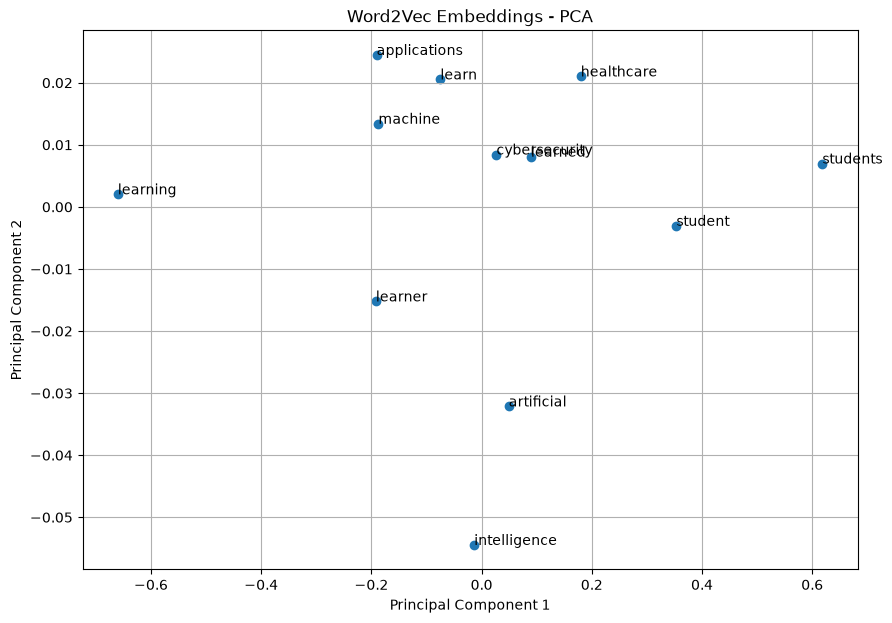

In [11]:
print("\n===== PART F: PCA VISUALIZATION =====")

visualization_words = [
    "artificial",
    "intelligence",
    "machine",
    "learning",
    "learn",
    "learned",
    "learner",
    "student",
    "students",
    "cybersecurity",
    "healthcare",
    "applications"
]


vectors = []

valid_words = []

for word in visualization_words:

    if word in w2v_model.wv:

        vectors.append(
            w2v_model.wv[word]
        )

        valid_words.append(word)


pca = PCA(n_components=2)

reduced_vectors = pca.fit_transform(vectors)


plt.figure(figsize=(10, 7))

plt.scatter(
    reduced_vectors[:, 0],
    reduced_vectors[:, 1]
)


for i, word in enumerate(valid_words):

    plt.annotate(
        word,
        (
            reduced_vectors[i, 0],
            reduced_vectors[i, 1]
        )
    )


plt.title("Word2Vec Embeddings - PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

## Notes / what to look for

**Corpus (Part A).** 30 sentences give a vocabulary of 129 tokens. All required words are present,
including `machinelearning` and `cybersecurity`. `machine-learning` is not in the vocabulary: the
corpus writes it as two words ("machine learning") or as `machinelearning`, never with a hyphen.

**Word2Vec (Part B).** Skip-gram with window 4 has the highest similarity values in this run
(top-5 neighbour scores about 0.993 to 0.998). CBOW with window 2 has the lowest (about 0.69 to 0.92).
Most top-5 lists are dominated by frequent words such as `to`, `can` and `learning`, and the Skip-gram
scores are mostly above 0.99. On 30 sentences the neighbour lists are therefore weak evidence of semantic
similarity. One consistent pattern: `machine` and `learning` are each other's top neighbours in all
four Word2Vec models.

**GloVe (Part C).** This is a count-based factorisation (log co-occurrence + SVD). Its neighbours
are noisy: `student` has `uses` (0.75) and `several` (0.62) as its top neighbours, and
`learning` has `good` and `through`. The intuition is that GloVe ranks words by how often they share
a window, so a word that co-occurs with many others (for example `several`, `studied`) scores
high even when it is not semantically related. The Part E table shows GloVe giving the
morphological pairs low similarity: 0.10 for learning-learner and 0.04 for learn-learning.

**FastText (Part D).** FastText builds a vector from character n-grams, so `machine-learning`
gets a vector although it never appears in the corpus. The script prints `Embedding generated: YES`.
Word2Vec and GloVe in `main.py` have no path for an out-of-vocabulary word, so FastText is the
only model here that can answer for the unseen string. Its vector is built from n-grams, so it
can be compared with the other vectors in the same way. The script does not compare it with
`learning` or any other word.

**Cosine similarity (Part E).** FastText gives 1.0000 for learning-learner and learn-learning and
at least 0.9998 for every pair. The scores are so close to 1 that the table does not separate the
pairs well, and the script's "best model" labels should be read with that in mind. Word2Vec
(Skip-gram, window 4) also gives values above 0.99 for every pair. GloVe is the only model
that gives clearly different values across pairs (0.04 to 0.45).

**Visualisation (Part F).** The PCA plot spreads the 12 words mainly along component 1:
`learning` is at the far left and `students` at the far right. `learn` and `applications` sit close
together, and `cybersecurity` and `learned` overlap. The 2-D projection is a rough view of 100-dimensional
vectors, and with 12 points it gives little evidence about clusters.

**Reproducibility.** `Word2Vec` and `FastText` use `workers=4`, so the exact neighbour lists and
similarity values can differ slightly between runs. The outputs saved here come from one run. No
internet access or downloaded model is used.